In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
import colorsys

# color-friendly plan
# RGB: EF8975; HSV: .028, .510, .937; V: .390~.990 (salmon)
# RGB: 6EBEAF; HSV: .469, .421, .745; V: .350~.850 (teal)
# RGB: 5983F6; HSV: .622, .683, .965; V: .480~.980 (blue)

# Sliver: C0C0C0; SlaterGray: 708090
Sliver = (.75, .75, .75)
Slater = (0.4375, 0.5, 0.5625)

def colorR (v: float = .7):
    return colorsys.hsv_to_rgb(.028, .510, .39+.6*v)
RED = '#d62728'

def colorG (v: float = .7):
    return colorsys.hsv_to_rgb(.469, .421, .35+.5*v)

def colorB (v: float = .7):
    return colorsys.hsv_to_rgb(.622, .683, .48+.5*v)

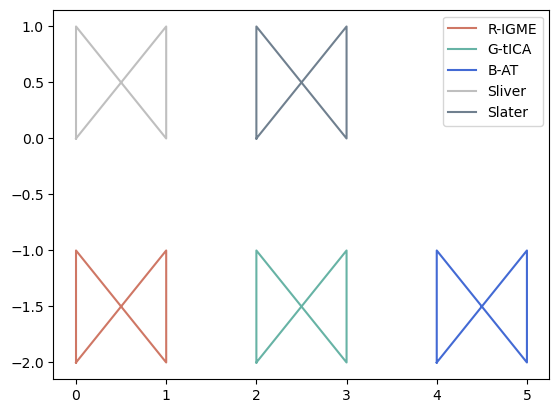

In [3]:
color_test_x, color_test_y = np.array((0, 1, 1, 0, 0)), np.array((0, 1, 0, 1, 0))
plt.plot(color_test_x, color_test_y-2, c=colorR(.7), label='R-IGME')
plt.plot(color_test_x+2, color_test_y-2, c=colorG(.7), label='G-tICA')
plt.plot(color_test_x+4, color_test_y-2, c=colorB(.7), label='B-AT')
plt.plot(color_test_x, color_test_y, c=Sliver, label='Sliver')
plt.plot(color_test_x+2, color_test_y, c=Slater, label='Slater')

plt.legend()
plt.show()

In [4]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


# Figure 1: 1b-1d

In [14]:
F1b = [np.load('Panel_1b1_tICexpansion.npz'), np.load('Panel_1b2_tICexpansion.npz'), np.load('Panel_1b3_tICexpansion.npz')]
F1b

[NpzFile 'Panel_1b1_tICexpansion.npz' with keys: x_tIC, counts, usage,
 NpzFile 'Panel_1b2_tICexpansion.npz' with keys: x_tIC, counts, usage,
 NpzFile 'Panel_1b3_tICexpansion.npz' with keys: x_tIC, counts, usage]

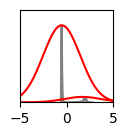

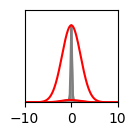

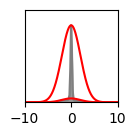

In [15]:
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

x_tIC, counts = F1b[0]['x_tIC'], F1b[0]['counts']
fig = plt.figure(figsize=(1.2,1.2))
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -0.54029688, 1.69770507
x_min, x_max = -5, 5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=345848), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=20174*1.2), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-5, 0, 5], fontsize=10)
plt.yticks([])
#plt.title('tIC1 basis')
plt.savefig('Panel_1b1_tICexpansion.svg', bbox_inches="tight", dpi=1000)
plt.show()

x_tIC, counts = F1b[1]['x_tIC'], F1b[1]['counts']
fig = plt.figure(figsize=(1.2,1.2))
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = 0.03775098, -0.11639949
x_min, x_max = -10, 10
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=410337), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=12364), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-10, 0 ,10], fontsize=10)
plt.yticks([])
#plt.title('tIC2 basis')
plt.savefig('Panel_1b2_tICexpansion.svg', bbox_inches="tight", dpi=1000)
plt.show()

x_tIC, counts = F1b[2]['x_tIC'], F1b[2]['counts']
fig = plt.figure(figsize=(1.2,1.2))
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = 0.01102431, -0.03105413
x_min, x_max = -10, 10
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=375699), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=18920), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-10, 0, 10], fontsize=10)
plt.yticks([])
#plt.title('tIC3 basis')
plt.savefig('Panel_1b3_tICexpansion.svg', bbox_inches="tight", dpi=1000)
plt.show()

## 1c 

In [5]:
F1c = np.load('Panel_1c_BootS.npz')
F1c

NpzFile 'Panel_1c_RMSE.npz' with keys: Kpred, Ktrue, Kerr, usage

In [18]:
def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()

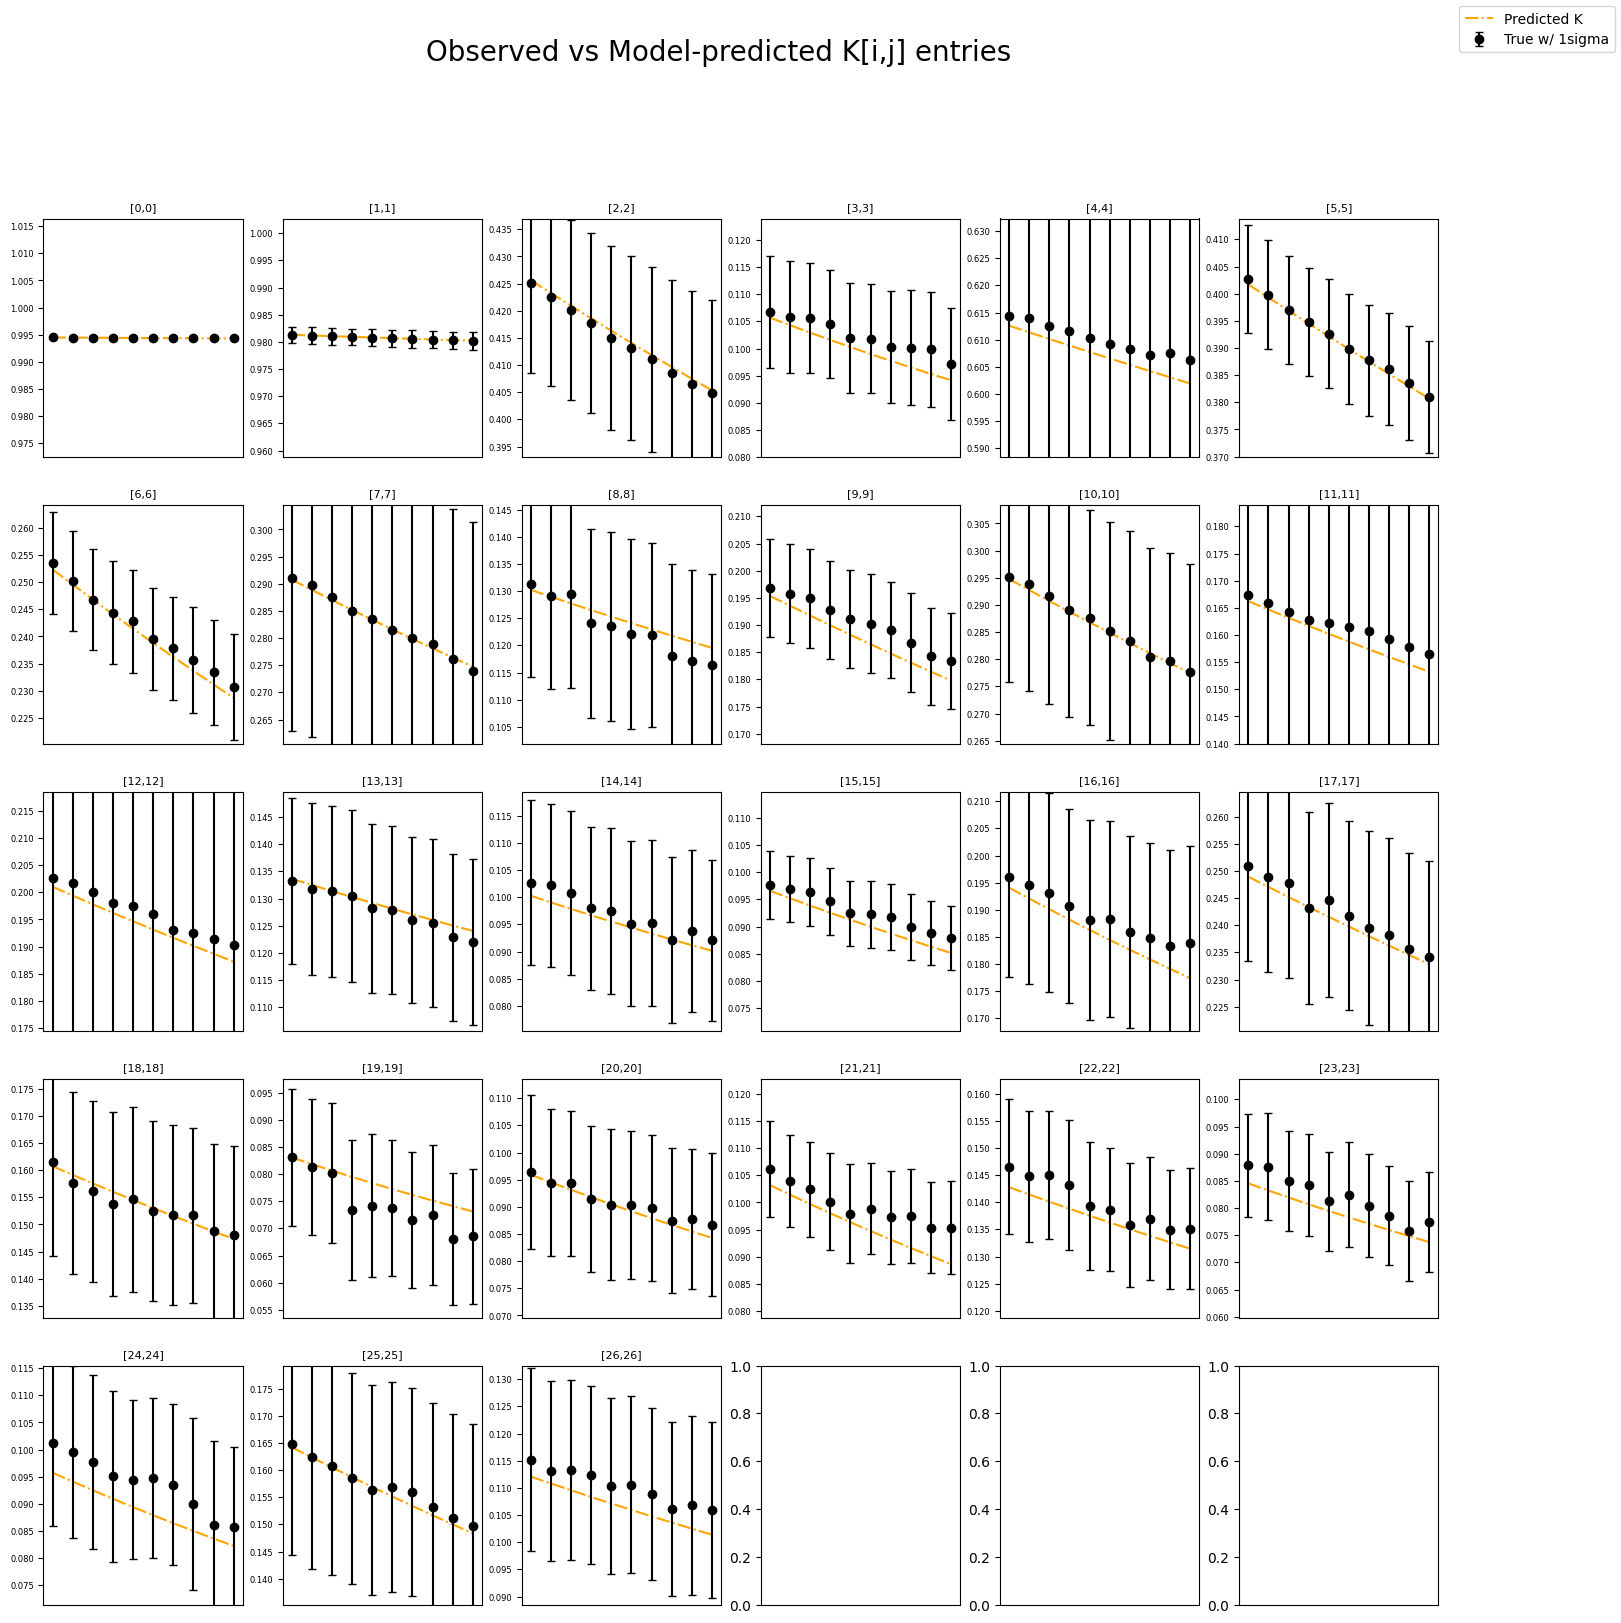

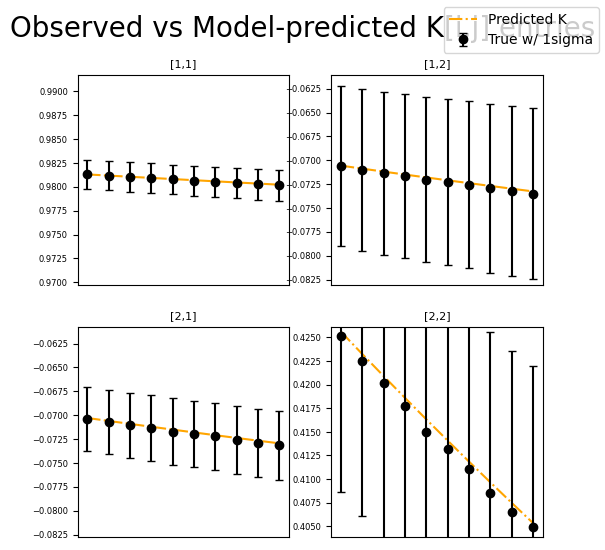

In [19]:
plot_error_bar(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[i,i] for i in range(27)], y_lim_range = .04)
plot_error_bar(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[1,1], [1,2], [2,1], [2,2]], y_lim_range = .02, fig_size = (6, 6))

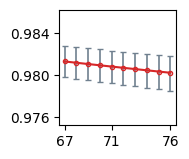

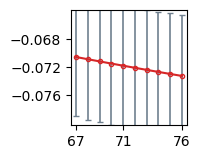

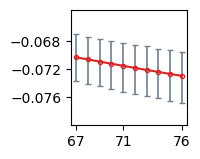

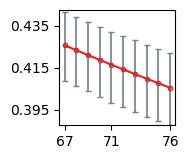

In [7]:
def error_bar_separate(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (1, 1)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))

    for idx in range(length):
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        fig, ax = plt.subplots(figsize=fig_size)
        if idx == 1:
            y_lim_range = .015
        if idx == 3:
            y_lim_range = .05
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.errorbar(t, y_true, yerr=y_err, fmt='none', linewidth=1.5, elinewidth=1.2, capsize=2, color=Slater, label='True w/ 1sigma')
        ax.plot(t, y_pred, '.-', markerfacecolor='none', label='IGME', color=RED)
        #ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)
        plt.xticks([0, 4, 9], [1+66, 5+66, 10+66], fontsize=10)
        if idx == 0:
            yticks = [.976, .980, .984]
        elif idx == 1 or idx == 2:
            yticks = [-.076, -.072, -.068]
        elif idx == 3:
            yticks = [.395, .415, .435]
        plt.yticks(yticks, fontsize=10)
        plt.savefig(f'Panel_1cBootS_{r[idx]}{c[idx]}.svg', bbox_inches="tight", dpi=1000, transparent=True)
        plt.show()

error_bar_separate(F1c['Kpred'], F1c['Ktrue'], F1c['Kerr'], [[1,1], [1,2], [2,1], [2,2]], fig_size = (1.5, 1.5))

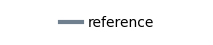

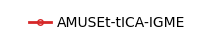

In [5]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=Slater, lw=3, label='reference'),
    Line2D([0], [0], color=RED, marker='.', lw=2, markersize=8,
           markerfacecolor='none', label='AMUSEt-tICA-IGME'),
]

fig_leg = plt.figure(figsize=(2.5, 0.3))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_elements[:1],
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.4
)

fig_leg.savefig("Panel_1cBootS_legend1.svg", bbox_inches='tight', transparent=True)
plt.show()

fig_leg = plt.figure(figsize=(2.5, 0.3))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_elements[1:],
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.4
)

fig_leg.savefig("Panel_1cBootS_legend2.svg", bbox_inches='tight', transparent=True)
plt.show()

## 1d

In [23]:
F1d = np.load('Panel_1d_ITS.npz')
F1d

NpzFile 'Panel_1d_ITS.npz' with keys: ITS_tICA, ITS_AT, ITS_IGME, usage

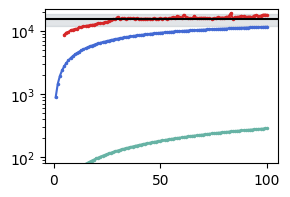

In [28]:
fig, ax = plt.subplots(figsize=(3, 2))
ax.set_yscale('log')
#plt.xlabel("lag time (ns)")
#plt.ylabel("ITS (ns)")

time_len = 100
ax.plot(range(1,time_len+1), F1d['ITS_tICA'][0][:time_len], '.-', markersize=3, c=colorG(), label='tICA')
ax.plot(range(1,time_len+1), F1d['ITS_AT'][0][:time_len], '.-', markersize=3, c=colorB(), label='AMUSEt-tICA')
ax.plot(range(5,time_len+1), F1d['ITS_IGME'][0][:time_len-4], '.-', markersize=3, c=RED, label='AMUSEt-tICA-IGME') 
y_max, y_min = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color=Slater, alpha=0.2, label='Gold Standard')
plt.axhline(.5*(y_min+y_max), color='k')

plt.xticks([0, 50, 100], fontsize=10)
plt.yticks([100, 1000, 10000], fontsize=10)
plt.ylim([80, 22000])
#plt.legend()
plt.savefig('Panel_1d_ITS.svg', bbox_inches="tight", dpi=1000)
plt.show()

# Figure 1e: RMSD plots

In [5]:
vmin = [-.0018, -0.3857e-3, -0.2923e-3, -0.6338e-3]
#vmin[1, 2, 3] are averages of negative values
vmean = [0, .01, .002, .005]
vmax = [.0005, .011, .015, .009]

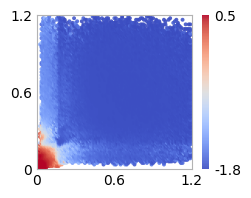

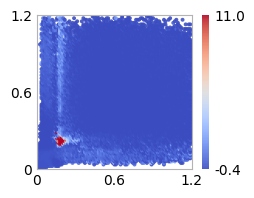

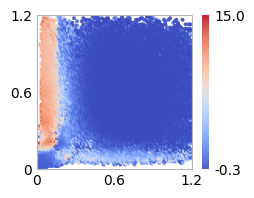

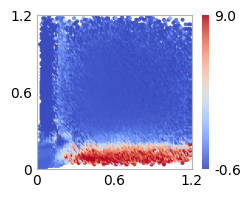

In [12]:
for i in range(4):
    read_in = []
    with open(f'FIP35_pred300lag-mode{i+1}_data.txt', "r") as f:
        for line in f:
            read_in.append(list(line.split()))
        read_in = np.array(read_in, dtype=np.float32)

    norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
    x, y, z = read_in[:, 0].flatten(), read_in[:, 1].flatten(), read_in[:, 2].flatten()
    mask = z == -10
#     if i != 0:
#         fil_z = z[(z<0) & (z>-8)]
#         print(i+1, np.mean(fil_z)*1000)
    fig = plt.figure(figsize=(2.5, 2))
    ax = fig.add_subplot(111)
    sc = plt.scatter(x[~mask], y[~mask], c=z[~mask], s=8, cmap="coolwarm", norm=norm,
                    edgecolors='none', linewidths=0, alpha=0.9, rasterized=True)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_color('0.7')     # gray (0=black, 1=white)
        spine.set_linewidth(0.8)
    #plt.xlabel("RMSD 1")
    #plt.ylabel("RMSD 2")
    #plt.title(f"CV[{i}]")
    plt.xlim([0, 1.2])
    plt.ylim([0, 1.2])
    ax.set_xticks([0, .6, 1.2], [0, 0.6, 1.2], fontsize=10)
    ax.set_yticks([0, .6, 1.2], [0, 0.6, 1.2], fontsize=10)
    cbar = plt.colorbar(sc)
    cbar.outline.set_visible(False)
    cbar.set_ticks([vmin[i], vmean[i], vmax[i]])
    cbar.set_ticklabels([f"{vmin[i]*1000:.1f}", f"", f"{vmax[i]*1000:.1f}"], fontsize=10) # f"{vmean[i]*1000:.1f}",
    cbar.ax.tick_params(width=0.8, length=0)
    
    plt.savefig(f'FIP35_CV_{i+1}.svg', bbox_inches="tight", dpi=1000, transparent=True)
    plt.show()

In [7]:
CVs = np.load("CVs_pred30-45.npy")[1:, :]
CVs.shape

(4, 1137344)

In [8]:
CV_label = []
for i in range(4):
    CV_label.append((CVs[i, :] > vmean[i]).astype(int))
state_label = CV_label[0] + 2*CV_label[1] + 4*CV_label[2] + 8*CV_label[3]

In [9]:
print(len(np.where((state_label!=0) & (state_label!=1) & (state_label!=2) & (state_label!=4) & (state_label!=8))[0]))
print(set(state_label[np.where((state_label!=0) & (state_label!=1) & (state_label!=2) & (state_label!=4) & (state_label!=8))]))

print(len(np.where(state_label == 0)[0]))
print(len(np.where(state_label == 1)[0]))
print(len(np.where(state_label == 2)[0]))
print(len(np.where(state_label == 4)[0]))
print(len(np.where(state_label == 8)[0]))

6512
{5, 9, 10, 12, 13}
233965
871324
4357
12199
8987


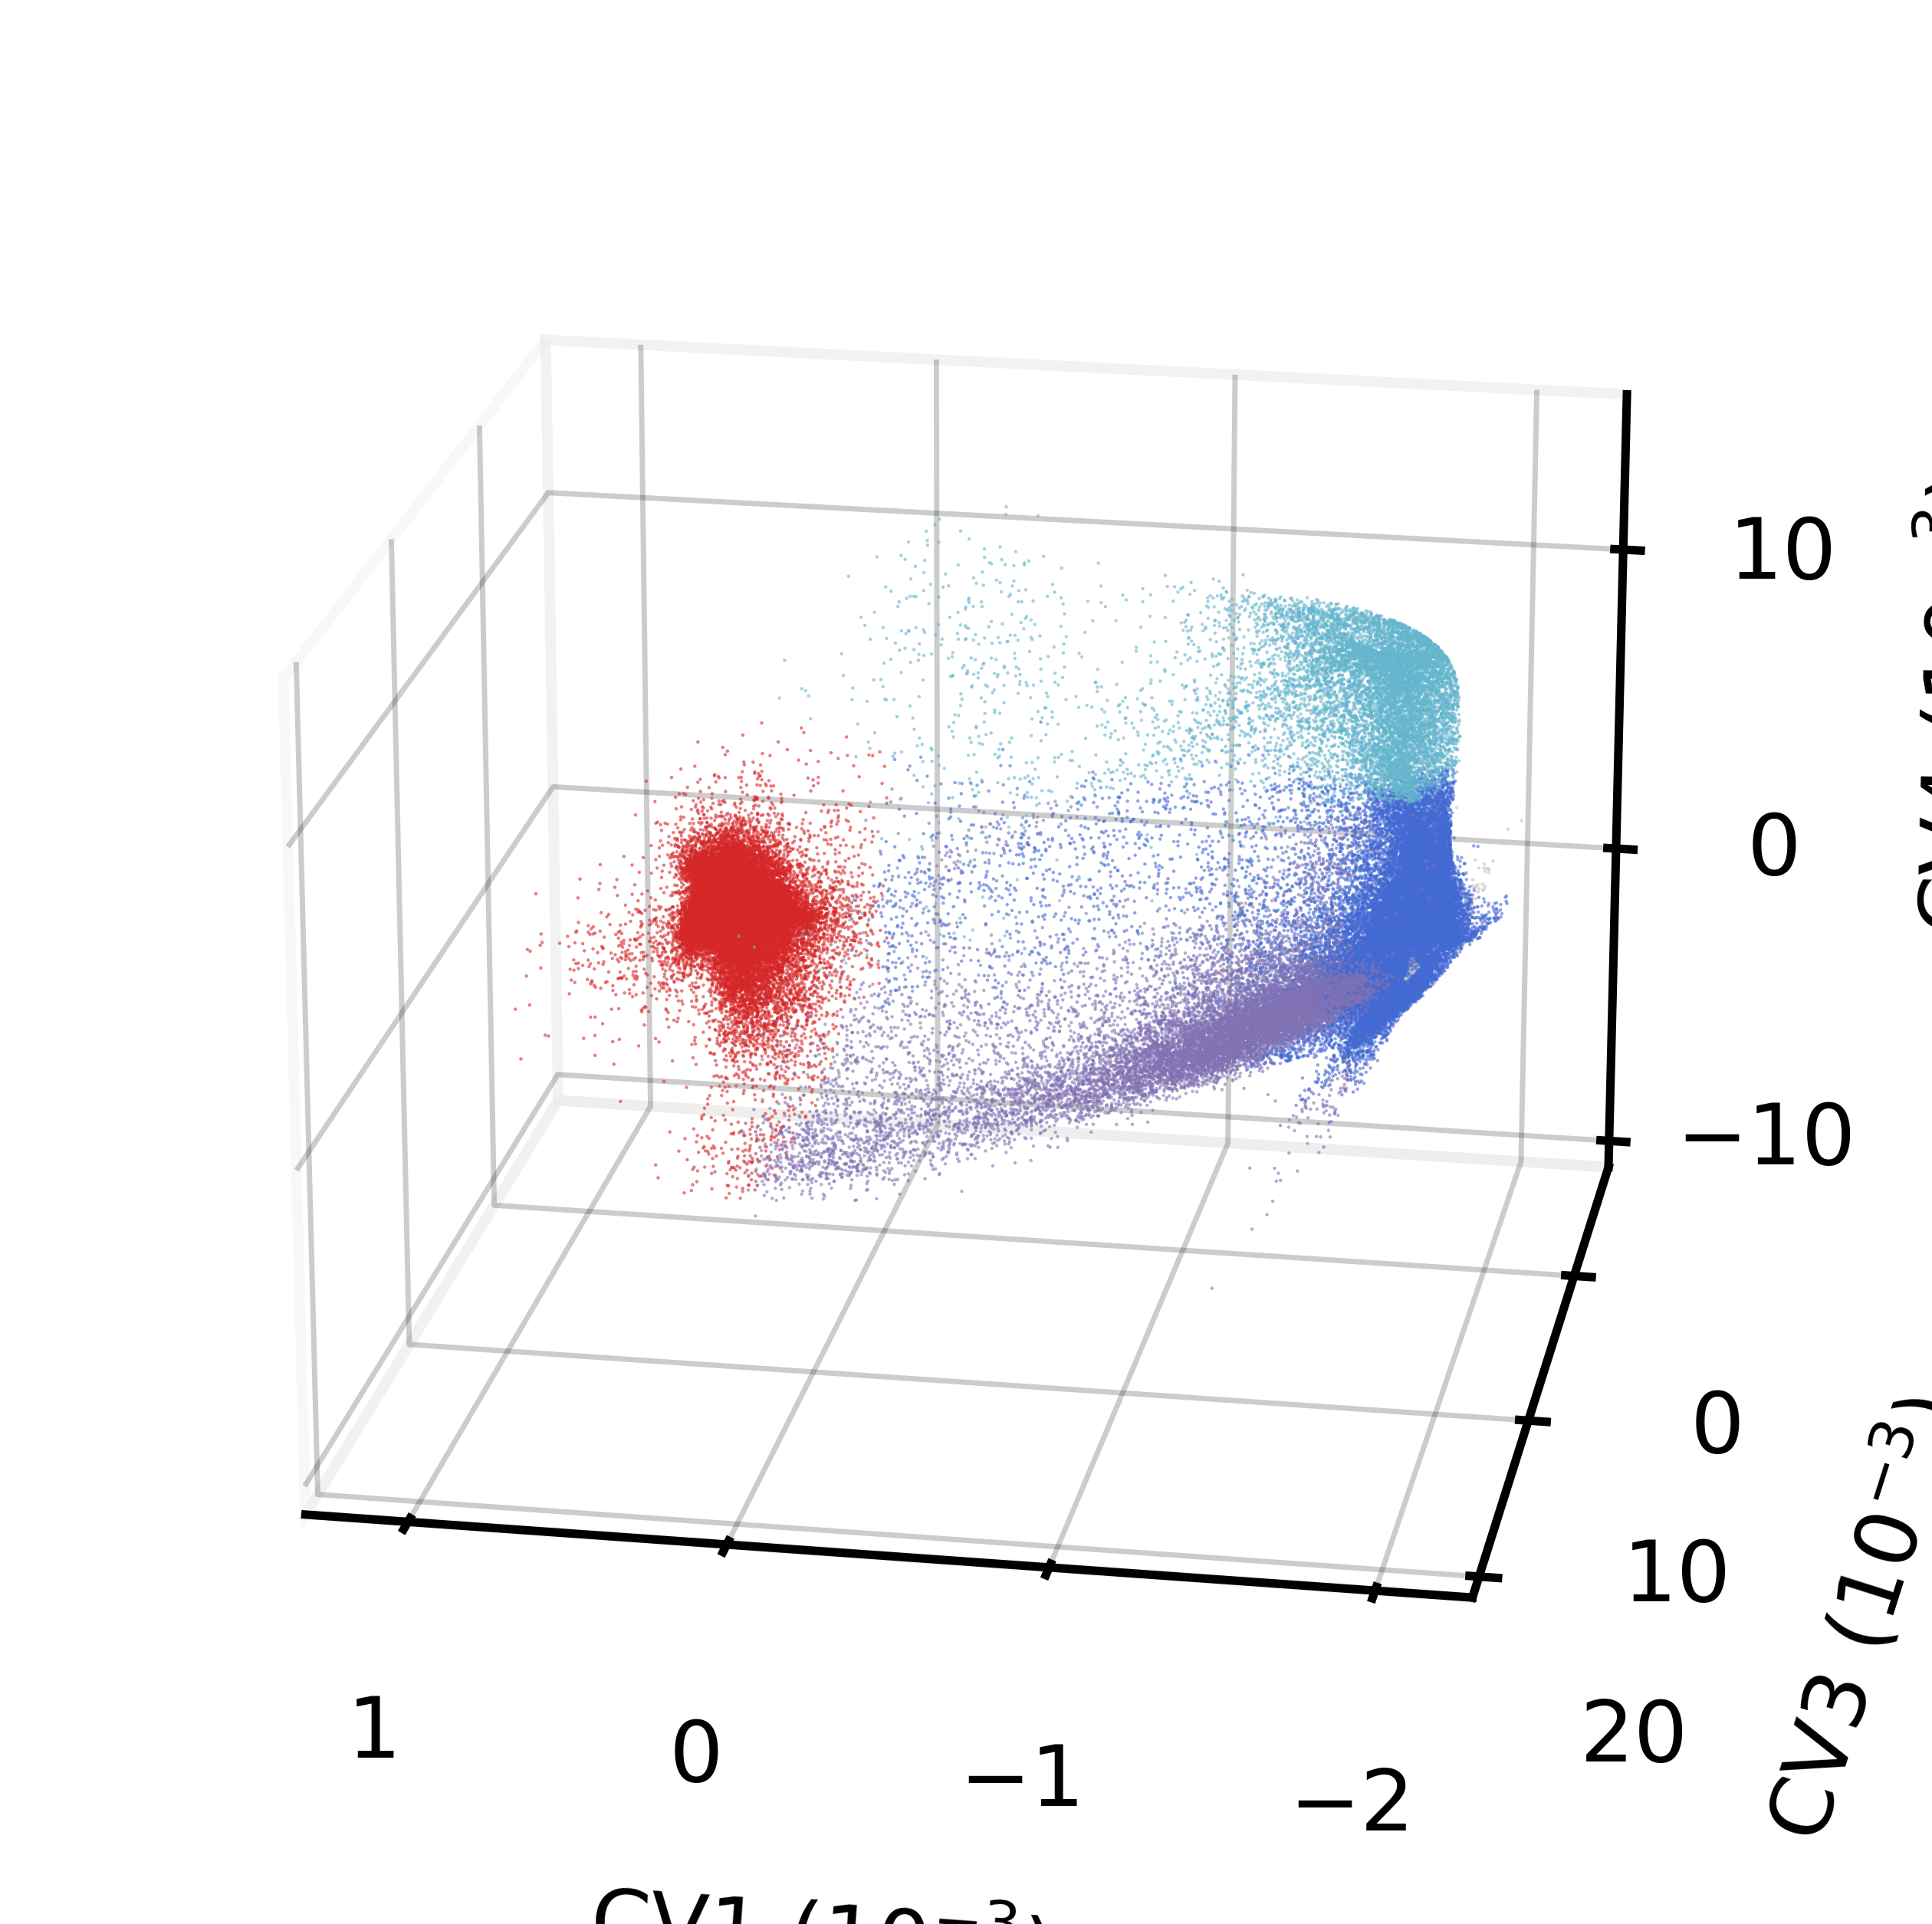

In [20]:
def RGB2str (rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)) 

x,y,z = 1000*np.real(CVs[0]), 1000*np.real(CVs[2]), 1000*np.real(CVs[3]) #CV 1,3,4
CV_color = [RGB2str(colorB()), RED, RGB2str(Sliver), '#FFFFFF',
           '#8172B3', RED, '#FFFFFF', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#64B5CD', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#FFFFFF', '#FFFFFF']

fig = plt.figure(figsize=(4, 3), dpi=1000)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, s=.1, c=[CV_color[_] for _ in state_label], alpha=0.6, edgecolors='none')
ax.set_xlabel(r"CV1 ($10^{-3}$)", fontsize=8)
ax.set_ylabel(r"CV3 ($10^{-3}$)", fontsize=8)
ax.set_zlabel(r"CV4 ($10^{-3}$)", fontsize=8)
plt.draw() 
#plt.title('CV1&3&4 value=labels')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
from matplotlib.ticker import MaxNLocator

ax.xaxis.set_major_locator(MaxNLocator(4)) 
ax.yaxis.set_major_locator(MaxNLocator(3))
ax.zaxis.set_major_locator(MaxNLocator(3))
ax.tick_params(axis='both', labelsize=8)
ax.tick_params(axis='z', labelsize=8)
ax.grid(True, linewidth=0.5, alpha=0.3)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linewidth'] = 0.5
    axis._axinfo["grid"]['color'] = (0, 0, 0, 0.2)
fig.patch.set_alpha(0)
ax.set_facecolor('white')

for t in ax.get_xticklabels():
    t.set_fontsize(8)
for t in ax.get_yticklabels():
    t.set_fontsize(8)
for t in ax.get_zticklabels():
    t.set_fontsize(8)

ax.xaxis.label.set_size(8)
ax.yaxis.label.set_size(8)
ax.zaxis.label.set_size(8)

ax.view_init(elev=20, azim=100)
# plt.savefig("plot.png", transparent=True)
plt.show()

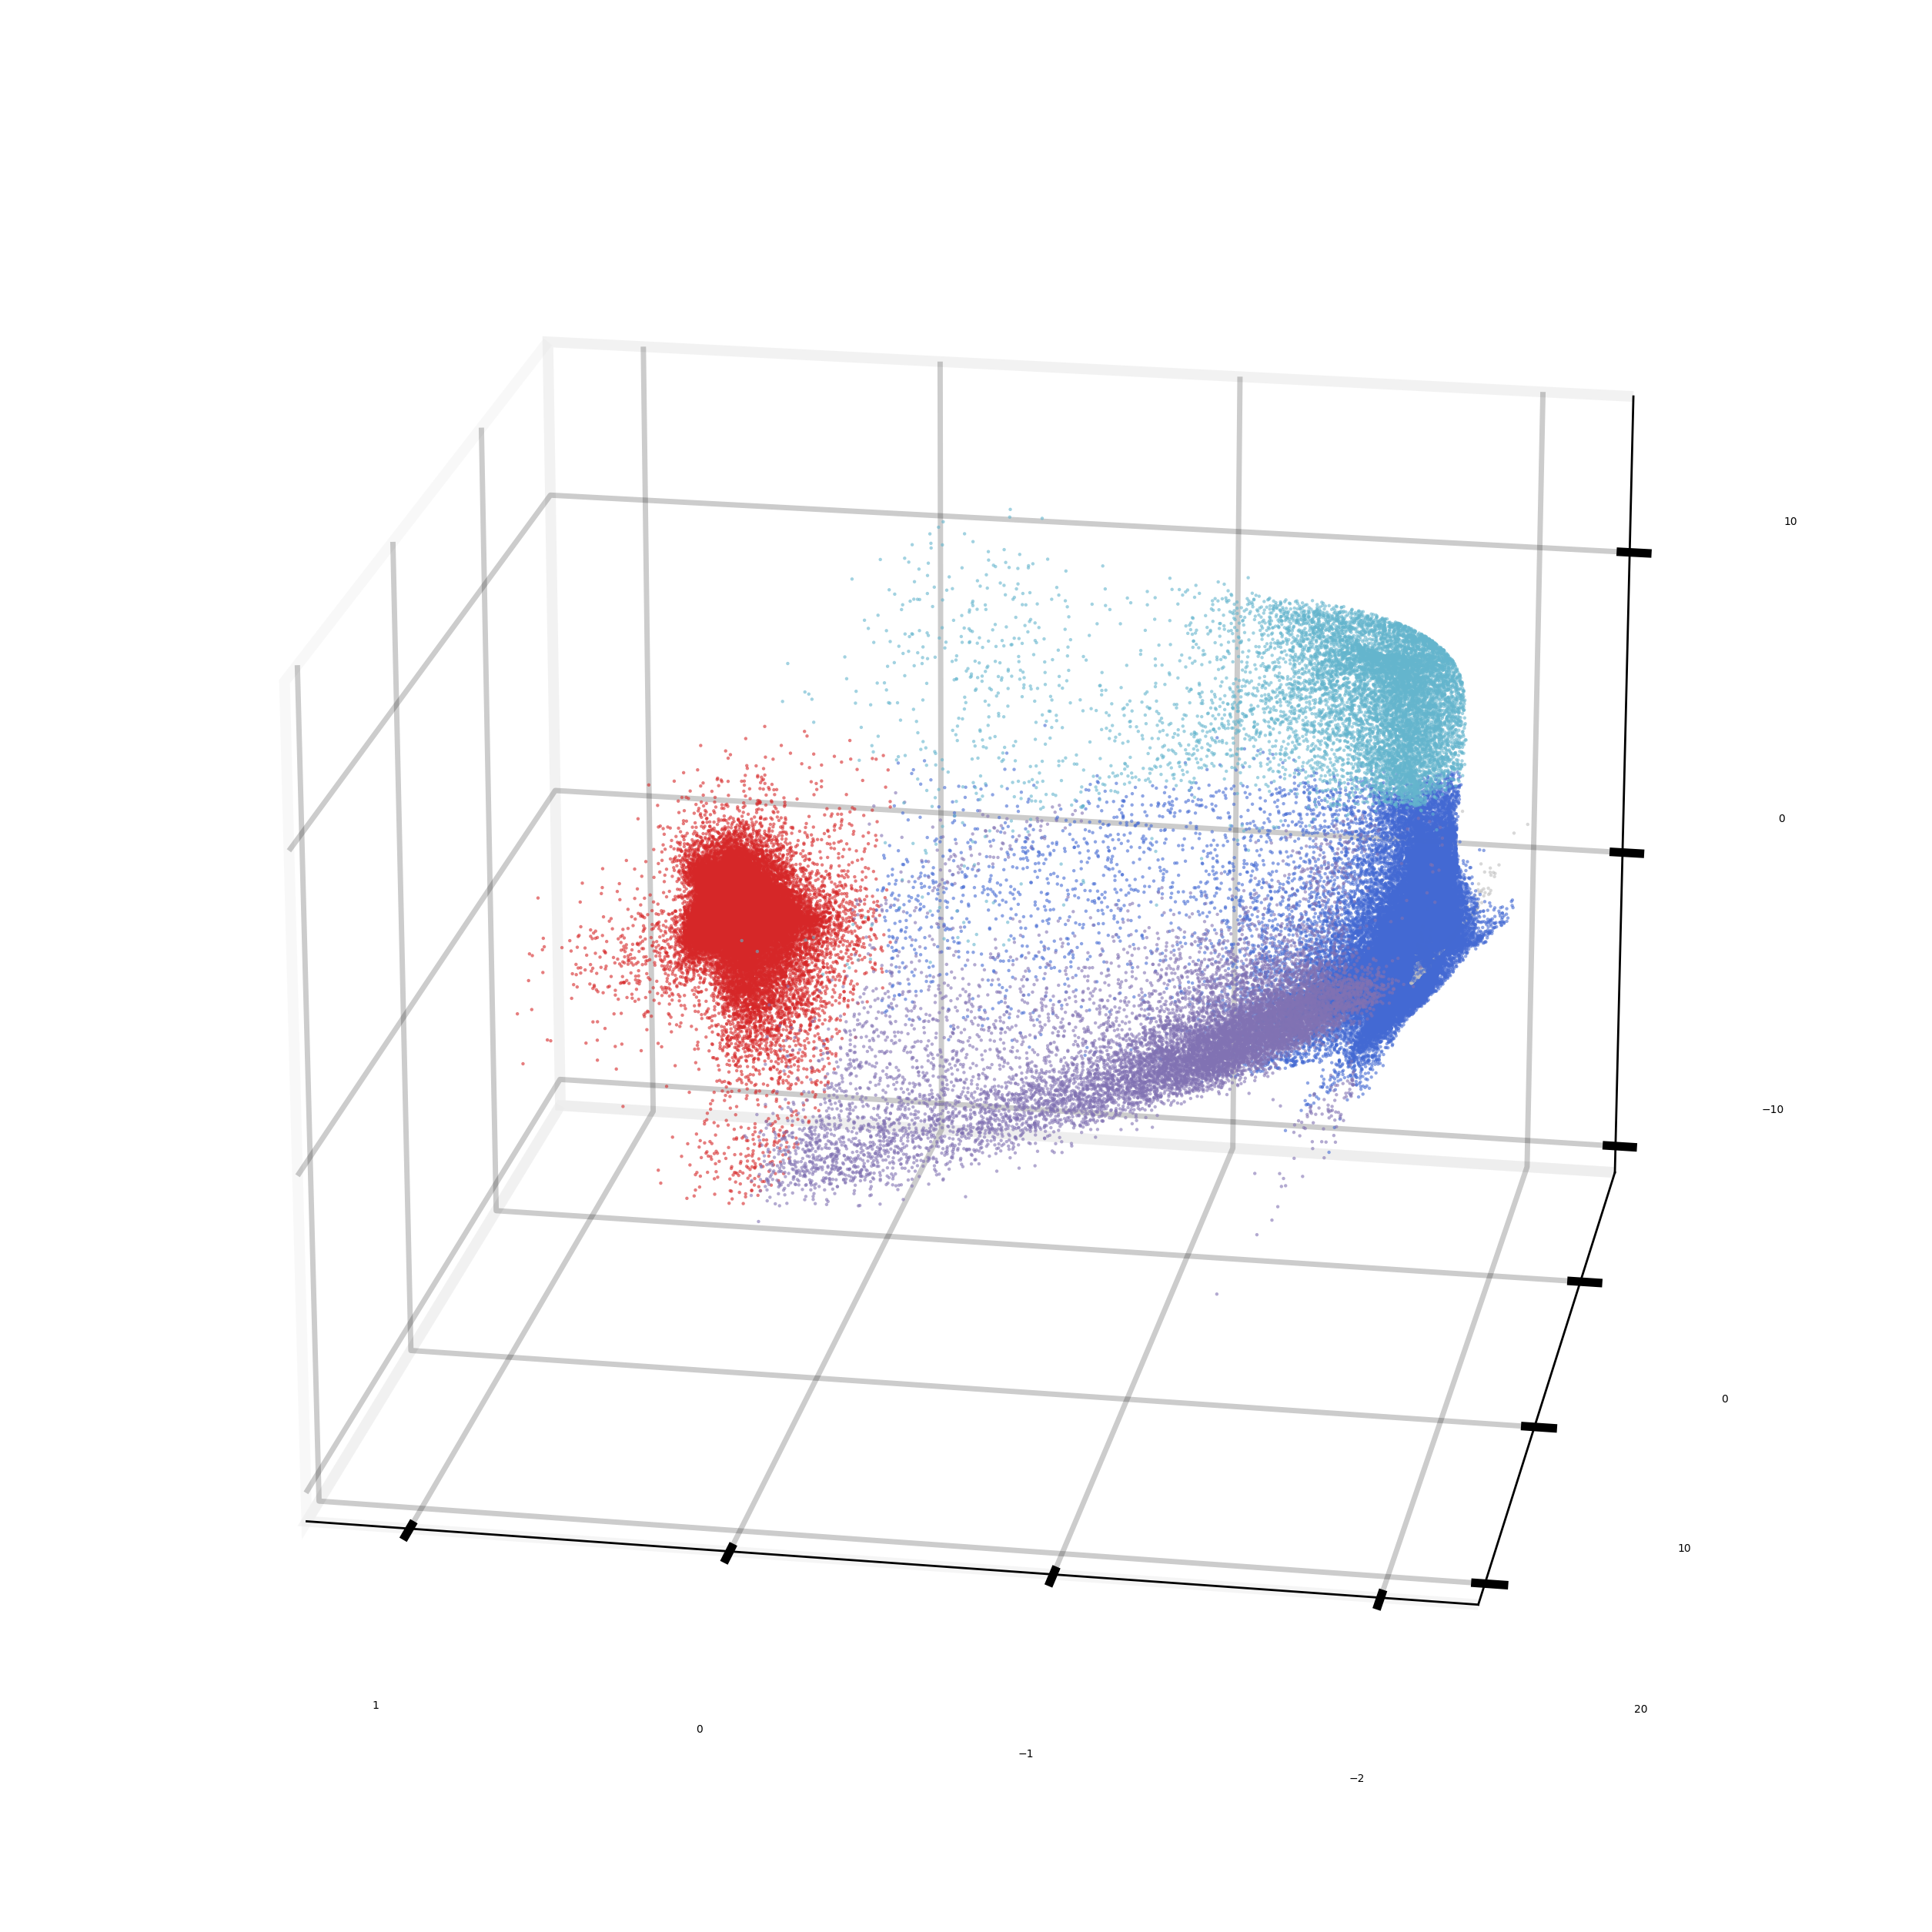

In [28]:
def RGB2str (rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)) 

x,y,z = 1000*np.real(CVs[0]), 1000*np.real(CVs[2]), 1000*np.real(CVs[3]) #CV 1,3,4
CV_color = [RGB2str(colorB()), RED, RGB2str(Sliver), '#FFFFFF',
           '#8172B3', RED, '#FFFFFF', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#64B5CD', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#FFFFFF', '#FFFFFF']

fig = plt.figure(figsize=(4, 3), dpi=1000)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, s=.1, c=[CV_color[_] for _ in state_label], alpha=0.6, edgecolors='none')
#ax.set_xlabel(r"CV1 ($10^{-3}$)", fontsize=8)
#ax.set_ylabel(r"CV3 ($10^{-3}$)", fontsize=8)
#ax.set_zlabel(r"CV4 ($10^{-3}$)", fontsize=8)
plt.draw() 
#plt.title('CV1&3&4 value=labels')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
from matplotlib.ticker import MaxNLocator

ax.xaxis.set_major_locator(MaxNLocator(4)) 
ax.yaxis.set_major_locator(MaxNLocator(3))
ax.zaxis.set_major_locator(MaxNLocator(3))

ax.grid(True, linewidth=0.5, alpha=0.3)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linewidth'] = 0.5
    axis._axinfo["grid"]['color'] = (0, 0, 0, 0.2)
fig.patch.set_alpha(0)
ax.set_facecolor('white')

for t in ax.get_xticklabels():
    t.set_fontsize(8)
for t in ax.get_yticklabels():
    t.set_fontsize(8)
for t in ax.get_zticklabels():
    t.set_fontsize(8)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.line.set_linewidth(0.2)

ax.set_xticks([-2, -1, 0, 1]) 
ax.tick_params(axis='x', labelsize=0)
ax.set_yticks([0, 10, 20]) 
ax.tick_params(axis='y', labelsize=0)
ax.set_zticks([-10, 0, 10]) 
ax.tick_params(axis='z', labelsize=0)

ax.view_init(elev=20, azim=100)
# plt.savefig("plot.png", transparent=True)
plt.show()

Plot start
plt.scatter ends.
Parameters settings done.


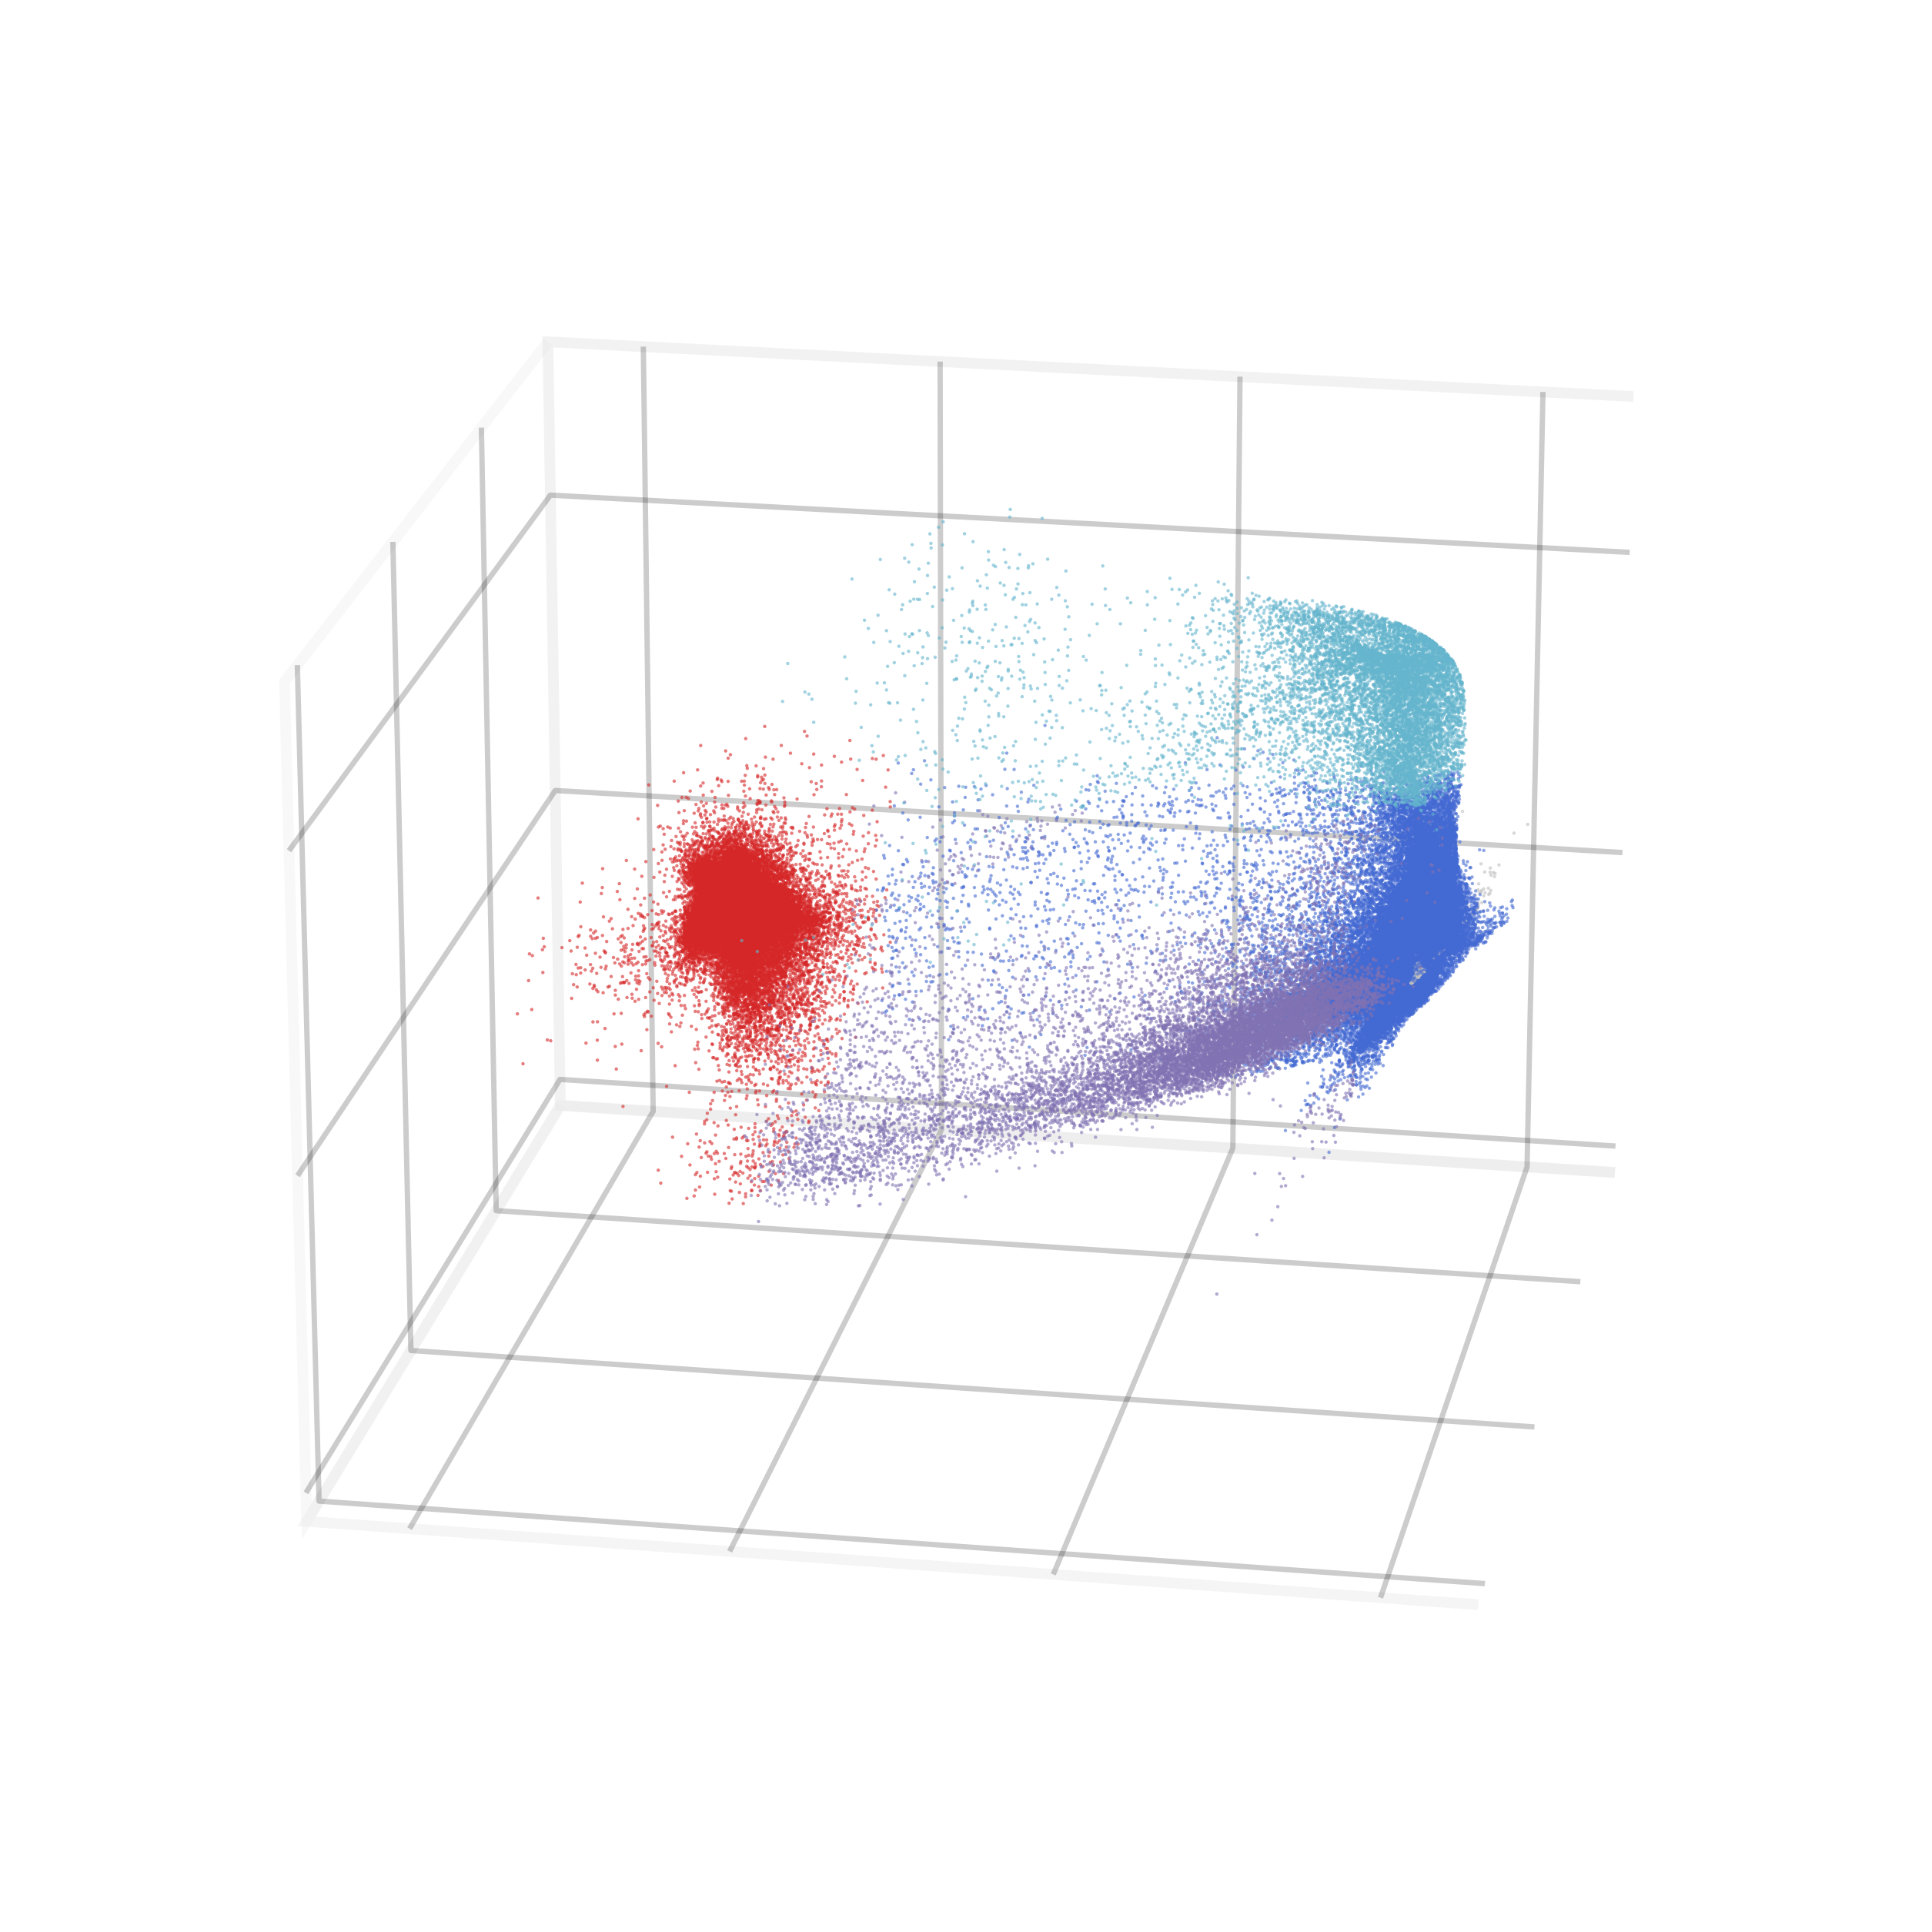

In [11]:
def RGB2str (rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)) 

x,y,z = 1000*np.real(CVs[0]), 1000*np.real(CVs[2]), 1000*np.real(CVs[3]) #CV 1,3,4
CV_color = [RGB2str(colorB()), RED, RGB2str(Sliver), '#FFFFFF',
           '#8172B3', RED, '#FFFFFF', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#64B5CD', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#FFFFFF', '#FFFFFF']

print("Plot start")
fig = plt.figure(figsize=(4, 3), dpi=1000)
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, s=.1, c=[CV_color[_] for _ in state_label], alpha=0.6, edgecolors='none', rasterized=True) #raster: saving filesize
plt.savefig("plot.pdf", dpi=300)
#ax.set_xlabel(r"CV1 ($10^{-3}$)", fontsize=8)
#ax.set_ylabel(r"CV3 ($10^{-3}$)", fontsize=8)
#ax.set_zlabel(r"CV4 ($10^{-3}$)", fontsize=8)
plt.draw() 
#plt.title('CV1&3&4 value=labels')

print("plt.scatter ends.")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linewidth=0.5, alpha=0.3)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['linewidth'] = 0.5
    axis._axinfo["grid"]['color'] = (0, 0, 0, 0.2)
    axis._axinfo["tick"]["inward_factor"] = 0
    axis._axinfo["tick"]["outward_factor"] = 0
    axis.line.set_linewidth(0)

ax.set_xticks([-2, -1, 0, 1]) 
ax.set_xticklabels([])
ax.set_yticks([0, 10, 20]) 
ax.set_yticklabels([])
ax.set_zticks([-10, 0, 10]) 
ax.set_zticklabels([])
ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='z', which='both', length=0)
print("Parameters settings done.")

ax.view_init(elev=20, azim=100)
plt.savefig("FIP35-folding.svg", bbox_inches="tight", dpi=400, transparent=True)
plt.show()

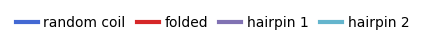

In [7]:
from matplotlib.lines import Line2D
def RGB2str (rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)) 
CV_color = [RGB2str(colorB()), RED, RGB2str(Sliver), '#FFFFFF',
           '#8172B3', RED, '#FFFFFF', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#64B5CD', '#FFFFFF',
           '#64B5CD', '#64B5CD', '#FFFFFF', '#FFFFFF']

legend_elements = [
    Line2D([0], [0], color=CV_color[0], lw=3, label='random coil'),
    Line2D([0], [0], color=CV_color[1], lw=3, label='folded'),
    Line2D([0], [0], color=CV_color[4], lw=3, label='hairpin 1'),
    Line2D([0], [0], color=CV_color[8], lw=3, label='hairpin 2'),
]

fig_leg = plt.figure(figsize=(2.5, 0.3))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_elements,
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=1.6,
    columnspacing=0.8,
    handletextpad=0.4
)

fig_leg.savefig("Folding-Legend.svg", bbox_inches='tight', transparent=True)
plt.show()

# Figure 2a: RMSE

In [5]:
F2a = [np.load('Panel_2a1_RMSE.npz'), np.load('Panel_2a2_RMSE.npz')]
F2a

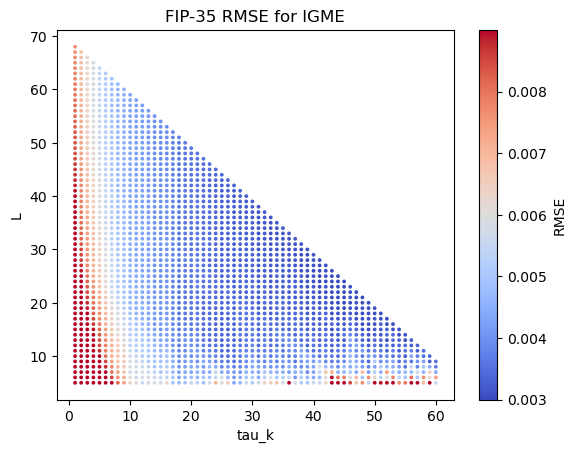

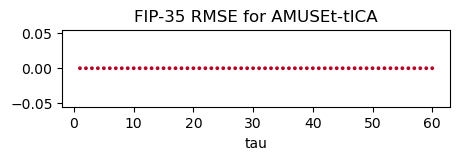

In [6]:
data = F2a[0]['data']
norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)
plt.scatter(data[0], data[1], s=3, c=data[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.title('FIP-35 RMSE for IGME')
plt.show() 

data = F2a[1]['data']
plt.figure(figsize=(5,1))
norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)
plt.scatter(range(1, 61), [0]*60, s=3, c=data, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('FIP-35 RMSE for AMUSEt-tICA')
plt.show()

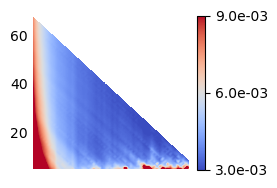

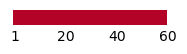

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# example scatter data
x = F2a[0]['data'][0]
y = F2a[0]['data'][1]
z = F2a[0]['data'][2]
norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)

# create grid
xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)
XI, YI = np.meshgrid(xi, yi)

# interpolate
ZI = griddata((x, y), z, (XI, YI), method='linear')

# plot
plt.figure(figsize=(2.5, 2))
plt.box(False)
plt.imshow(
    ZI,
    extent=(x.min(), x.max(), y.min(), y.max()),
    origin='lower',
    aspect='auto',
    cmap='coolwarm',
    norm = norm
)
plt.xticks([])
plt.yticks([20, 40, 60], fontsize=10)
ax = plt.gca()
ax.tick_params(axis='both', which='both', length=0)
cbar = plt.colorbar()
cbar.set_ticks([.003, .006, .009])
cbar.set_ticklabels([f"{.003:.1e}", f"{.006:.1e}", f"{.009:.1e}"], fontsize=10)
plt.savefig(f'Panel_2a1_RMSE.svg', bbox_inches="tight", dpi=1000)
plt.show()

fig, ax = plt.subplots(figsize=(2, .2))
plt.box(False)
ax.imshow(F2a[1]['data'][np.newaxis, :], 
          aspect='auto', cmap='coolwarm', norm=norm, interpolation="bilinear")
ax.set_xticks([0, 20, 40, 60])
ax.set_xticklabels([1, 20, 40, 60], fontsize=10)
ax.set_yticks([])                 # remove vertical axis
ax.tick_params(axis='x', length=0)

#plt.xlabel(f'$\tau$')
#plt.title('Ala2 RMSE for AMUSEt-tICA')
plt.savefig(f'Panel_2a2_RMSE.svg', bbox_inches="tight", dpi=1000)
plt.show()

In [5]:
F2b = [np.load('Panel_2b1_savingRank.npz'), np.load('Panel_2b2_savingLagT.npz')]
F2b

[NpzFile 'Panel_2b1_savingRank.npz' with keys: title, usage,
 NpzFile 'Panel_2b2_savingLagT.npz' with keys: title, data, usage]

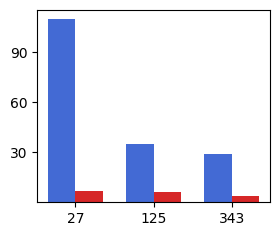

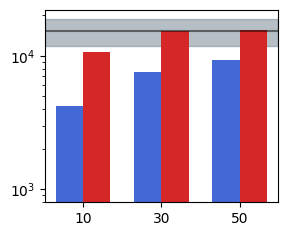

In [7]:
# limit = 11849 ns
AT_tau_cs = [110, 35, 29]
IGME_tau_cs = [7, 6, 4]
categories = [27, 125, 343]
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(3, 2.5))
ax.bar(x - width/2, AT_tau_cs, width, color=colorB(), label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, color=RED, label='AMUSEt-tICA-IGME')
plt.xticks(x, categories, fontsize=10)
plt.yticks([30, 60, 90], fontsize=10)
#ax.set_xlabel("Number of Basis")
#ax.set_ylabel("min traj len / ns")

#plt.legend()
plt.savefig('Panel_2b1_savingRank.svg', bbox_inches="tight", dpi=1000)
plt.show() 

data = F2b[1]['data']
data = data[:, :3]
x = np.arange(len(data[0]))
width = 0.35

fig, ax = plt.subplots(figsize = (3, 2.5))
y_min, y_max = 18670.1, 11849.1
plt.axhline(.5*(y_min+y_max), color='k', alpha=0.5, label='Gold Standard')
plt.axhspan(y_min, y_max, color=Slater, alpha=0.5, label='Gold Standard err')
ax.set_yscale('log')
ax.bar(x - width/2, data[1], width, color=colorB(), label='AMUSEt-tICA w/ rank 27')
ax.bar(x + width/2, data[2], width, color=RED, label='AMUSEt-tICA-IGME w/ rank 27')

plt.xticks(x, [int(_) for _ in data[0]], fontsize=10)
#ax.set_xlabel(r"lag time / ns ($\tau$ or $\tau_k$+L)")
#ax.set_ylabel("ITS / ns")
plt.ylim([800, 22000])
plt.yticks([1000, 10000], fontsize=10)

#plt.legend()
plt.savefig('Panel_2b2_savingLagT.svg', bbox_inches="tight", dpi=1000)
plt.show()